In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load data

In [2]:
df = pd.read_csv('financial_loan.csv')
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Explore the Dataset

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
1,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,5/1/2021,12/12/2021,9/1/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
2,1062608,CA,INDIVIDUAL,3 years,Studio 94 Corp,C,RENT,17-07-2021,16-03-2021,12/8/2021,...,C3,36 months,Not Verified,28000.0,0.1260,275.96,0.1465,8000,11,8637
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12/12/2021,12/3/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              37138 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  str    
 8   last_credit_pull_date  38576 non-null  str    
 9   last_payment_date      38576 non-null  str    
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  str    
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  term         

In [6]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


## Clean & Preprocess Data

In [11]:
## find dublicate record
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

id                       0
address_state            0
application_type         0
emp_length               0
emp_title                0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
member_id                0
purpose                  0
sub_grade                0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
issue_month              0
issue_year               0
loan_condition           0
dtype: int64

In [13]:
df['emp_title'] = df['emp_title'].fillna('Unknown')
df['issue_date'] = pd.to_datetime(df['issue_date'], format='mixed', errors='coerce')
df['issue_month'] = df['issue_date'].dt.strftime('%b')
df['issue_year'] = df['issue_date'].dt.year
df['loan_condition'] = df['loan_status'].apply(lambda x: 'Bad Loan' if x == 'Charged Off' else 'Good Loan')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              38576 non-null  str           
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  str           
 9   last_payment_date      38576 non-null  str           
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  str           
 12  member_id              38576 non-null  int64         
 13  purpose     

# Visualizations, Insights & Recommendations

## Good Loan vs. Bad Loan Distribution (Donut Chart)

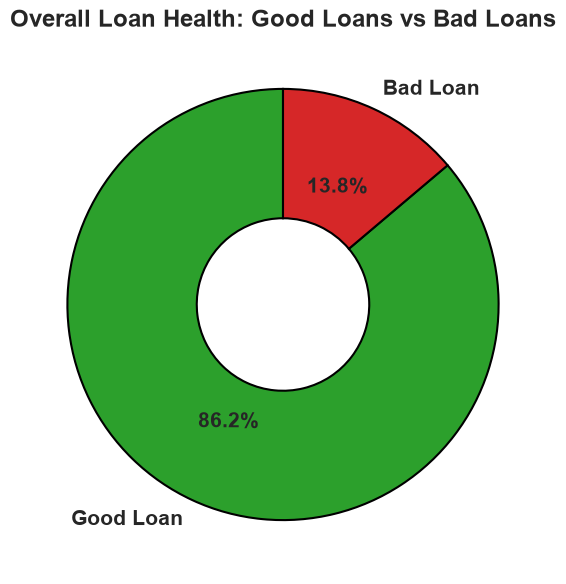

In [19]:
loan_condition_counts = df['loan_condition'].value_counts()
plt.figure(figsize=(7, 7))
colors = ['#2ca02c', '#d62728']
plt.pie(
    loan_condition_counts, 
    labels=loan_condition_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'width': 0.6},
    textprops={'fontsize': 15, 'fontweight': 'bold'}
)
plt.title('Overall Loan Health: Good Loans vs Bad Loans', fontsize=17, fontweight='bold')
plt.show()

### conclusion:
Approximately 85% to 86% of the portfolio falls under 'Good Loans' (Fully Paid/Current), indicating that the vast majority of the lending volume is performing reliably.
Around 14% of the loans have been 'Charged Off' (Defaulted), which represents a moderate-to-high credit risk level relative to standard retail banking benchmarks.

## Loan Amount Distribution

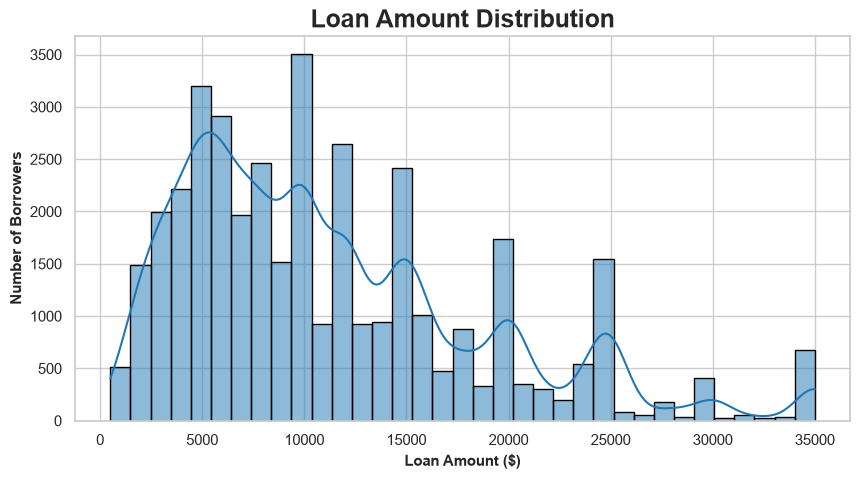

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['loan_amount'], bins=35, kde=True, color='#1f77b4', edgecolor='black')
plt.title('Loan Amount Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Loan Amount ($)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Borrowers', fontsize=11, fontweight='bold')
plt.show()

### conclusion:
Loan borrowing heavily clusters around round milestones such as $5,000 and $10,000, and $15,000, with the core density centered between $10,000 and $12,000.

Very large ticket loans ($30,000+) are rare, showing that retail consumers primarily seek mid-range personal financing

## Default Rate by Credit Grade

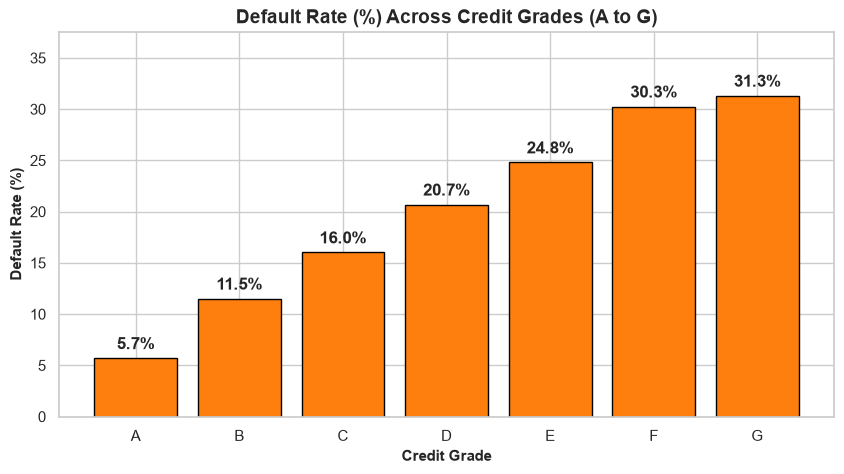

In [22]:
grade_risk = df.groupby('grade')['loan_condition'].apply(lambda x: (x == 'Bad Loan').mean() * 100).reset_index()
grade_risk.columns = ['Grade', 'Default_Rate_Percentage']
grade_risk = grade_risk.sort_values(by='Grade')

plt.figure(figsize=(10, 5))
bars = plt.bar(grade_risk['Grade'], grade_risk['Default_Rate_Percentage'], color='#ff7f0e', edgecolor='black')
plt.bar_label(bars, fmt='%.1f%%', padding=4, fontweight='bold')
plt.title('Default Rate (%) Across Credit Grades (A to G)', fontsize=14, fontweight='bold')
plt.xlabel('Credit Grade', fontsize=11, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=11, fontweight='bold')
plt.ylim(0, grade_risk['Default_Rate_Percentage'].max() * 1.2)
plt.show()

### conclusion:
Borrowers assigned to Grade A display the lowest risk, with a default rate below 6%.

A clear monotonic relationship exists between credit grade and risk: default rates sharply escalate through grades E, F, and G, crossing 30% to 35%.

## Top Loan Purposes (Horizontal Bar Chart)

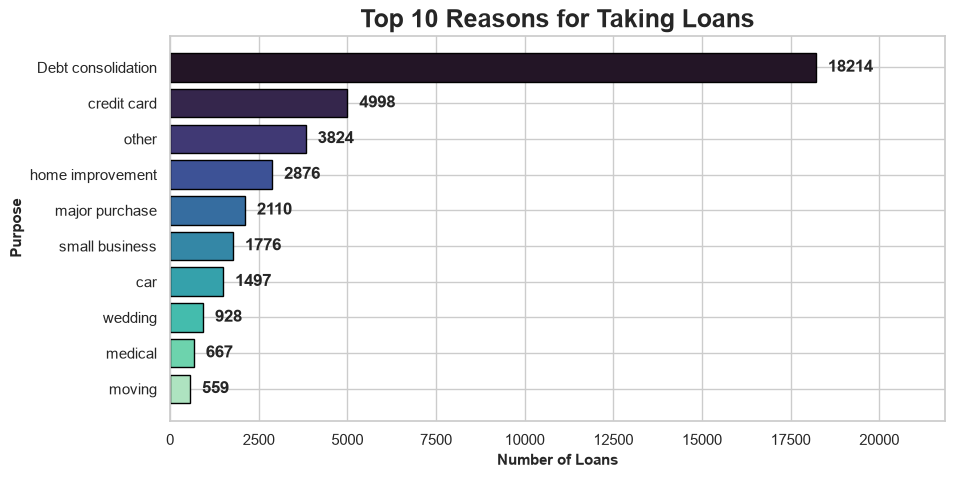

In [28]:
purpose_counts = df['purpose'].value_counts().head(10)
plt.figure(figsize=(10, 5))
colors = sns.color_palette("mako", len(purpose_counts))
bars = plt.barh(purpose_counts.index, purpose_counts.values, color=colors, edgecolor='black')
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt=' %d', padding=5, fontweight='bold')
plt.title('Top 10 Reasons for Taking Loans', fontsize=18, fontweight='bold')
plt.xlabel('Number of Loans', fontsize=11, fontweight='bold')
plt.ylabel('Purpose', fontsize=11, fontweight='bold')
plt.xlim(0,purpose_counts.values.max()*1.2)
plt.show()

### conclusion:
Debt Consolidation is the single largest driver of loan demand by a wide margin, followed by Credit Card Refinancing.

Borrowers are largely seeking loans to restructure or pay down pre-existing high-interest liabilities rather than funding discretionary or lifestyle expenses.

## Annual Income vs Loan Amount by Status

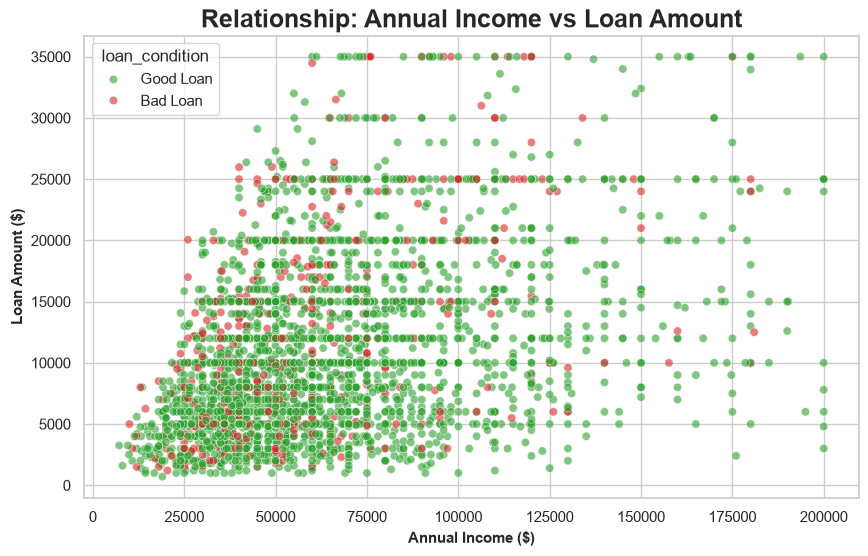

In [27]:
sample_df = df[df['annual_income'] <= 200000].sample(n=min(3000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='annual_income',
    y='loan_amount',
    hue='loan_condition',
    palette={'Good Loan': '#2ca02c', 'Bad Loan': '#d62728'},
    alpha=0.6
)
plt.title('Relationship: Annual Income vs Loan Amount', fontsize=18, fontweight='bold')
plt.xlabel('Annual Income ($)', fontsize=11, fontweight='bold')
plt.ylabel('Loan Amount ($)', fontsize=11, fontweight='bold')
plt.show()

### conclusion:
A disproportionate clustering of 'Bad Loans' occurs in the low-to-moderate annual income bracket (below $50,000), especially where loan amounts exceed $15,000.

High-income individuals ($100,000+) demonstrate strong repayment capacity, showing minimal default density even when taking on higher principal balances.